In [11]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scripts.train_model import circuit_training
from scr.qsvdd_core.data_loader import QuantumDataLoader
from scripts.test_model import test

## Constants

In [30]:
dataset = 'fraud'
n_train = 0 ; latent_dim = 3
num_params_conv = 5 # 375 # para qcnn, 5 para lcqhnn
cost_func = 'svdd'
batch_size = 64
steps = 16*1000//batch_size # 16*500//batch_size para qcnn e 16*1000//batch_size para lcqnn
learning_rate = 0.001

## Dataset

In [3]:
print("Diretório atual:", os.getcwd())
print("Arquivos nesta pasta:", os.listdir())

Diretório atual: D:\projects\QSVDD2\notebooks
Arquivos nesta pasta: ['circuit_visualization.ipynb', 'data_visualization.ipynb', 'noise_data_visualization.ipynb', 'original_qcnn_experiments']


In [3]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset carregado com sucesso!\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


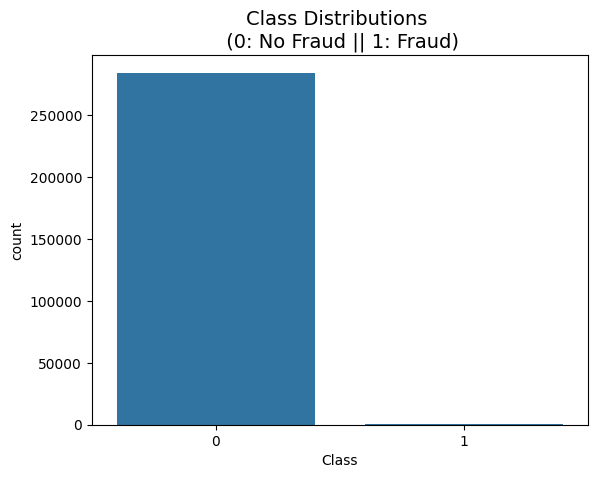

In [7]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [36]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [37]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [38]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [4]:
loader = QuantumDataLoader()

X_quantum, y = loader.prepare_fraud_data(df)

print(f"Features para o circuito: {X_quantum.shape}") # Deve mostrar (n_linhas, 32)
print(f"Labels: {y.shape}")

Features para o circuito: (284807, 32)
Labels: (284807,)


In [5]:
"""
One-class Training:
Separação em exemplos normais e fraudulentos
O QSVDD irá aprender o que é normal.
"""
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# Treino
# coleta 1000 exemplos normais para o treino
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X_quantum[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

# X_train contém apenas transações legítimas
X_train = X_train_normal
Y_train = y_train_normal

# Teste (balanceado)
# O código retira 100 exemplos normais que não foram usados no treino
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X_quantum[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

# O código retira 100 exemplos de fraudes.
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X_quantum[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# cria um conjunto de teste com 200 exemplos (50% normal, 50% fraude)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)


center = np.zeros(latent_dim)
center_train = np.tile(center, (len(X_train), 1))


print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 32)
Y_train shape: (1000,)
X_test_normal shape: (100, 32)
X_test_abnormal shape: (100, 32)
X_test shape: (200, 32)
Y_test shape: (200,)
center_train shape: (1000, 3)


### Noiseless Training

### QSVDD com ansatz LCQHNN

In [31]:
train_Xdata = X_train
train_Ydata = center_train
start_time = time.time()
loss_history, est_params, param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     n_params=num_params_conv,
                     batch_size=batch_size,
                     learning_rate=learning_rate,
                     steps=steps,
                     )
)
end_time = time.time()

total_runtime = (end_time - start_time) / 60
print(f"Total runtime: {total_runtime} minutes for batch size {batch_size}")

iteration: 0 | cost: 0.008763
iteration: 1 | cost: 0.008067
iteration: 2 | cost: 0.008743
iteration: 3 | cost: 0.008228
iteration: 4 | cost: 0.007936
iteration: 5 | cost: 0.008299
iteration: 6 | cost: 0.008679
iteration: 7 | cost: 0.007765
iteration: 8 | cost: 0.007678
iteration: 9 | cost: 0.007336
iteration: 10 | cost: 0.007871
iteration: 11 | cost: 0.007514
iteration: 12 | cost: 0.007161
iteration: 13 | cost: 0.007248
iteration: 14 | cost: 0.007150
iteration: 15 | cost: 0.006966
iteration: 16 | cost: 0.006776
iteration: 17 | cost: 0.006609
iteration: 18 | cost: 0.007793
iteration: 19 | cost: 0.007161
iteration: 20 | cost: 0.006809
iteration: 21 | cost: 0.006759
iteration: 22 | cost: 0.006140
iteration: 23 | cost: 0.006225
iteration: 24 | cost: 0.006699
iteration: 25 | cost: 0.007164
iteration: 26 | cost: 0.006061
iteration: 27 | cost: 0.005608
iteration: 28 | cost: 0.006228
iteration: 29 | cost: 0.006317
iteration: 30 | cost: 0.005567
iteration: 31 | cost: 0.005349
iteration: 32 | co

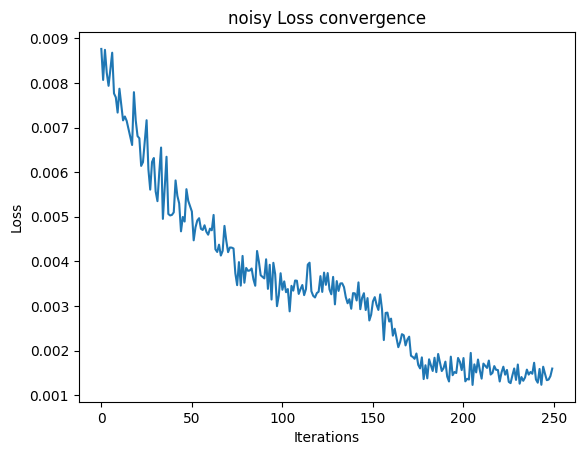

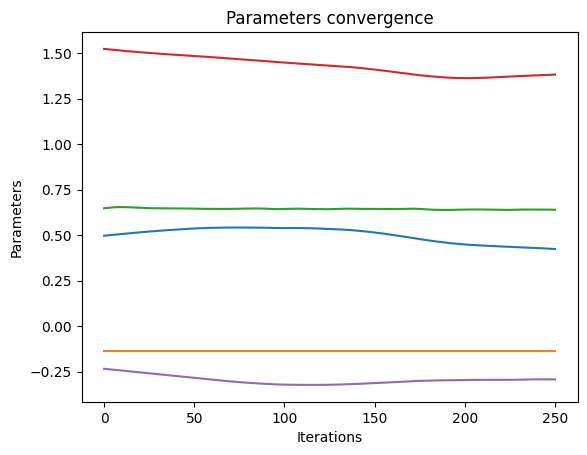

In [32]:
plt.style.use('default')
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("noisy Loss convergence")
plt.show()

plt.plot(param_history)
plt.xlabel("Iterations")
plt.ylabel("Parameters")
plt.title("Parameters convergence")
plt.show()

In [33]:
auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, est_params, center_train, noisy=True)

Processing class 0 (label 0) | Samples: 100
Finished class 0 in 2.97s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 2.96s
Test completed in 5.93s | AUC: 0.9089


### QSVDD com ansatz QCNN

In [42]:
train_Xdata = X_train
train_Ydata = center_train
start_time = time.time()
loss_history, est_params, param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     n_params=num_params_conv,
                     batch_size=batch_size,
                     learning_rate=learning_rate,
                     steps=steps,
                     )
)
end_time = time.time()

total_runtime = (end_time - start_time) / 60
print(f"Total runtime: {total_runtime} minutes for batch size {batch_size}")

/home/jvfg/Documents/ORG/QSVDD2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:943: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


iteration: 0 | cost: 0.031032
iteration: 1 | cost: 0.029356
iteration: 2 | cost: 0.027694
iteration: 3 | cost: 0.023709
iteration: 4 | cost: 0.020307
iteration: 5 | cost: 0.020381
iteration: 6 | cost: 0.018557
iteration: 7 | cost: 0.015562
iteration: 8 | cost: 0.012919
iteration: 9 | cost: 0.016536
iteration: 10 | cost: 0.014296
iteration: 11 | cost: 0.011425
iteration: 12 | cost: 0.008803
iteration: 13 | cost: 0.007567
iteration: 14 | cost: 0.007737
iteration: 15 | cost: 0.007233
iteration: 16 | cost: 0.005477
iteration: 17 | cost: 0.005204
iteration: 18 | cost: 0.004803
iteration: 19 | cost: 0.005824
iteration: 20 | cost: 0.003350
iteration: 21 | cost: 0.003839
iteration: 22 | cost: 0.002725
iteration: 23 | cost: 0.002932
iteration: 24 | cost: 0.002413
iteration: 25 | cost: 0.001388
iteration: 26 | cost: 0.000898
iteration: 27 | cost: 0.001289
iteration: 28 | cost: 0.001166
iteration: 29 | cost: 0.000545
iteration: 30 | cost: 0.000776
iteration: 31 | cost: 0.002069
iteration: 32 | co

### Saving Training

In [44]:
np.savetxt(f"../results/training/B{batch_size}S{steps}_loss_history.npy", loss_history)
np.savetxt(f"../results/training/B{batch_size}S{steps}_est_params.npy", est_params)
np.savetxt(f"../results/training/B{batch_size}S{steps}_param_history.npy", param_history)

In [ ]:
plt.style.use('default')
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss convergence")
plt.show()

plt.plot(param_history)
plt.xlabel("Iterations")
plt.ylabel("Parameters")
plt.title("Parameters convergence")
plt.show()

### Noisy Training

In [ ]:
train_Xdata = X_train
train_Ydata = center_train
start_time = time.time()
loss_history_noise, est_params_noise, param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     n_params=num_params_conv,
                     batch_size=batch_size,
                     learning_rate=learning_rate,
                     steps=steps//2,
                     noisy=True
                     )
)
end_time = time.time()#%%

total_runtime = (end_time - start_time) / 60
print(f"Total runtime: {total_runtime} minutes for batch size {batch_size}")

## Saving Noisy Training

In [ ]:
np.savetxt(f"../results/training/B{batch_size}S{steps}_loss_history_noise.npy", loss_history_noise)
np.savetxt(f"../results/training/B{batch_size}S{steps}_est_params_noise.npy", est_params_noise)
np.savetxt(f"../results/training/B{batch_size}S{steps}_param_history_noise.npy", param_history_noise)

In [ ]:
plt.style.use('default')
plt.plot(loss_history_noise)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("noisy Loss convergence")
plt.show()

plt.plot(param_history_noise)
plt.xlabel("Iterations")
plt.ylabel("Parameters")
plt.title("Parameters convergence")
plt.show()

## Noiseless Test

In [ ]:
from scripts.test_model import test

auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, est_params, center_train)

## Saving Noiseless Test

In [ ]:
import os

file_name = f"B{batch_size:02d}S{steps}.txt"
results_dir = os.path.join("..", "results", "test")
file_path = os.path.join(results_dir, file_name)

os.makedirs(results_dir, exist_ok=True)

with open(file_path, "w") as f:
    f.write("Test completed.\n")
    f.write(f"Batch Size = {batch_size} \nSteps = {steps} \n")
    f.write(f"Training time: {total_runtime:.2f} minutes\n")
    f.write(f"AUC: {auc:.4f}\n")


print(f"Success! Result saved to: {file_path}")
print(f"Training time: {total_runtime:.2f} minutes")
print(f"AUC Score: {auc:.4f}")

In [ ]:
plt.hist(y_pred)

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="{:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Noisy Test

In [ ]:
auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, est_params_noise, center_train, noisy=True)

## Saving Noisy Test

In [ ]:
file_name = f"batch{batch_size:02d}_steps{steps//2}_noisy.txt"
results_dir = os.path.join("..", "results", "test")
file_path = os.path.join(results_dir, file_name)

os.makedirs(results_dir, exist_ok=True)

with open(file_path, "w") as f:
    f.write("Test completed.\n")
    f.write(f"Batch Size = {batch_size} \nSteps = {steps} \n")
    f.write(f"Training time: {total_runtime:.2f} minutes\n")
    f.write(f"AUC: {auc:.4f}\n")

print(f"Success! Result saved to: {file_path}")
print(f"Training time: {total_runtime:.2f} minutes")
print(f"AUC Score: {auc:.4f}")

In [ ]:
plt.hist(y_pred)

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="AUC Score: {:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve noisy")
plt.legend(loc="lower right")
plt.show()

In [ ]:
np.savetxt()